In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
def parse_conllu_flat(filepath):
    words = []
    tags = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
                
            parts = line.split('\t')
            if len(parts) > 3:
                words.append(parts[1])
                tags.append(parts[3])  
                
    return words, tags

In [3]:
print("Loading Indonesian GSD datasets...")
train_words, train_tags = parse_conllu_flat('id_gsd-ud-train.conllu')
test_words, test_tags = parse_conllu_flat('id_gsd-ud-test.conllu')

print(f"Training items: {len(train_words)}")
print(f"Testing items:  {len(test_words)}")

print("\nVectorizing data...")
vectorizer = CountVectorizer(analyzer='word', token_pattern=r".+", lowercase=False)

X_train = vectorizer.fit_transform(train_words)
X_test = vectorizer.transform(test_words)

print(f"Vocabulary Size: {len(vectorizer.get_feature_names_out())}")

Loading Indonesian GSD datasets...
Training items: 97531
Testing items:  11780

Vectorizing data...
Vocabulary Size: 19223


In [4]:
print("Training Naive Bayes (MultinomialNB)...")
model = MultinomialNB()
model.fit(X_train, train_tags)

Training Naive Bayes (MultinomialNB)...


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [5]:
print("Predicting...")
y_pred = model.predict(X_test)

acc = accuracy_score(test_tags, y_pred)
print(f"\n>>> ACCURACY: {acc:.2%}")

print("\n>>> CLASSIFICATION REPORT:")
print(classification_report(test_tags, y_pred, zero_division=0))

Predicting...

>>> ACCURACY: 82.89%

>>> CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         ADJ       0.85      0.54      0.66       425
         ADP       0.95      0.97      0.96      1153
         ADV       0.86      0.77      0.81       490
         AUX       0.99      0.99      0.99        96
       CCONJ       0.96      0.91      0.94       375
         DET       0.95      0.91      0.93       374
        NOUN       0.60      0.95      0.74      2555
         NUM       0.93      0.71      0.81       407
        PART       0.97      0.73      0.84        49
        PRON       0.99      0.93      0.96       498
       PROPN       0.92      0.53      0.67      2211
       PUNCT       1.00      1.00      1.00      1724
       SCONJ       0.82      0.63      0.71       142
         SYM       1.00      0.67      0.80        30
        VERB       0.95      0.83      0.88      1250
           X       0.00      0.00      0.00         1

    accuracy    

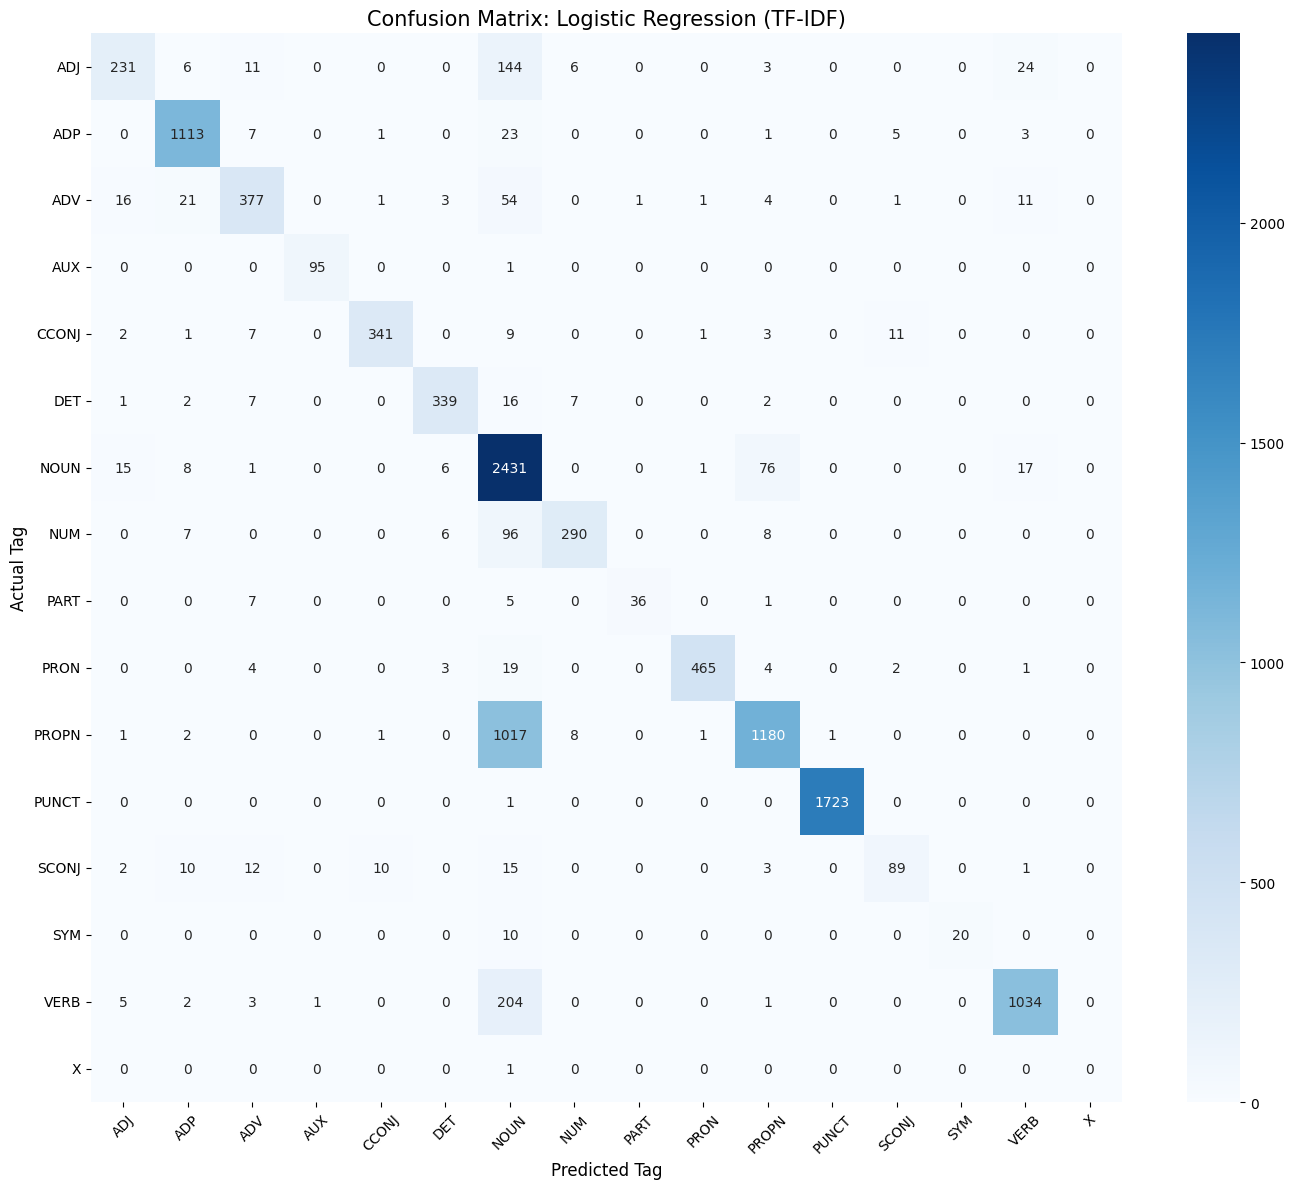

In [6]:
labels = sorted(list(set(test_tags)))
cm = confusion_matrix(test_tags, y_pred, labels=labels)
plt.figure(figsize=(14, 12))

_ = sns.heatmap(cm, 
            annot=True,         
            fmt='d',            
            cmap='Blues',       
            xticklabels=labels, 
            yticklabels=labels)

plt.xlabel('Predicted Tag', fontsize=12)
plt.ylabel('Actual Tag', fontsize=12)
plt.title('Confusion Matrix: Logistic Regression (TF-IDF)', fontsize=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()